In [2]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
import evaluate

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

plt.rcParams["figure.figsize"] = (12, 4)

# Mount Drive


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
def seed_everything(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# Run on a GPU runtime (Colab: Runtime -> Change runtime type -> GPU, e.g. T4/L4/A100).
# Falls back to CPU only if no GPU is attached.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE_TYPE = device.type  # "cuda" or "cpu"
print(f"Using device: {device}  (type: {DEVICE_TYPE})")
if DEVICE_TYPE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: no GPU detected — select a GPU runtime for reasonable training speed.")

Using device: cuda  (type: cuda)
GPU: NVIDIA L4


# Paths

In [4]:
# checkpoint-5750 is the best/final model (epoch 10, val CER=0.0399 on Bentham)
CHECKPOINT_DIR = "/content/drive/MyDrive/Bentham/models/bentham_trocr_checkpoint/checkpoint-5750"
OPTIMIZER_PATH = "/content/drive/MyDrive/Bentham/models/bentham_trocr_checkpoint/checkpoint-5750/optimizer.pt"


MAX_TARGET_LENGTH = 128
BATCH_SIZE        = 8
NUM_BEAMS         = 4


print(CHECKPOINT_DIR)

/content/drive/MyDrive/Bentham/models/bentham_trocr_checkpoint/checkpoint-5750


## Load Model & Optimizer

In [5]:
# The Trainer checkpoint stores only model weights — no processor/tokenizer files.
# The processor (image preprocessor + tokenizer) is unchanged by fine-tuning,
# so load it from the original base model; load the model from the checkpoint.
BASE_MODEL = "microsoft/trocr-base-handwritten"

processor = TrOCRProcessor.from_pretrained(BASE_MODEL)
model     = VisionEncoderDecoderModel.from_pretrained(CHECKPOINT_DIR)
model.to(device)
model.eval()
print("Processor loaded from", BASE_MODEL)
print("Model loaded from    ", CHECKPOINT_DIR)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

Processor loaded from microsoft/trocr-base-handwritten
Model loaded from     /content/drive/MyDrive/Bentham/models/bentham_trocr_checkpoint/checkpoint-5750


In [ ]:
# Optimizer state — only needed when resuming training.
# Loaded here to confirm it pairs with checkpoint-5750.
# optimizer_state = torch.load(OPTIMIZER_PATH, map_location="cpu")
# print("Optimizer loaded from", OPTIMIZER_PATH)
# print("  Keys:", list(optimizer_state.keys()) if isinstance(optimizer_state, dict) else type(optimizer_state))

# Continue Fine-Tuning on READ (ICFHR-2016 Bozen) Dataset

We resume from the Bentham checkpoint (`checkpoint-5750`) and keep training on the German
READ/Bozen data. Unlike Bentham, the READ dataset is **page-level**: full-page `.JPG` scans plus
PAGE-XML (`page/page/*.xml`) that hold per-line polygons and transcriptions. So the steps are:

1. Parse each page's XML → crop every `TextLine` to its own line image + grab its `Unicode` text.
2. Feed those cropped lines through the **same** Dataset / Trainer pipeline used for Bentham.

> **Note:** we do **not** load the 2.5 GB Bentham `optimizer-002.pt`. Starting a fresh optimizer is
> the right choice when adapting to a new dataset — and it avoids the RAM crash on small machines.
> Skip the optimizer-load cell above when running this section.

In [6]:
from transformers import (
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    default_data_collator,
)

# --- READ dataset paths (edit these for your Google Drive layout) ---
# Local repo layout this mirrors:
#   .../PublicData/{Training,Validation}/Images/<page>.JPG
#   .../PublicData/{Training,Validation}/page/page/<page>.xml
READ_ROOT = "/content/drive/MyDrive/READ/Train-And-Val-ICFHR-2016/PublicData"

# Where to write cropped line images. Use fast LOCAL Colab disk (not Drive) —
# Drive is very slow with thousands of tiny files. This is ephemeral, which is fine:
# the crops are a rebuildable cache.
CROP_DIR = "/content/read_lines"

# Where new checkpoints are saved (Drive, so they survive the session)
READ_OUTPUT_DIR = "/content/drive/MyDrive/READ/models/read_trocr_checkpoint"

# --- training hyper-parameters ---
EPOCHS        = 8
LEARNING_RATE = 2e-5   # lower than Bentham's 3e-5 since we resume from a trained model

# BATCH_SIZE, MAX_TARGET_LENGTH and NUM_BEAMS are defined in the Paths cell above.
print("READ_ROOT       =", READ_ROOT)
print("CROP_DIR        =", CROP_DIR)
print("READ_OUTPUT_DIR =", READ_OUTPUT_DIR)

READ_ROOT       = /content/drive/MyDrive/READ/Train-And-Val-ICFHR-2016/PublicData
CROP_DIR        = /content/read_lines
READ_OUTPUT_DIR = /content/drive/MyDrive/READ/models/read_trocr_checkpoint


In [ ]:
import xml.etree.ElementTree as ET
from glob import glob

def _local(tag: str) -> str:
    """Strip the XML namespace, e.g. '{...}TextLine' -> 'TextLine'."""
    return tag.rsplit("}", 1)[-1]

def find_page_dir(split_dir: str) -> str:
    """PAGE XMLs live in <split>/page/page in this dataset; fall back to <split>/page."""
    for cand in (os.path.join(split_dir, "page", "page"),
                 os.path.join(split_dir, "page")):
        if glob(os.path.join(cand, "*.xml")):
            return cand
    raise FileNotFoundError(f"No PAGE XML found under {split_dir}/page")

def parse_page_xml(xml_path: str):
    """Return (image_filename, [(line_id, polygon_points, text), ...]) for one page."""
    root = ET.parse(xml_path).getroot()
    page = next((el for el in root.iter() if _local(el.tag) == "Page"), None)
    img_name = page.attrib.get("imageFilename") if page is not None else None

    lines = []
    for tl in root.iter():
        if _local(tl.tag) != "TextLine":
            continue
        coords, text = None, None
        for ch in tl:
            lt = _local(ch.tag)
            if lt == "Coords":
                coords = ch.attrib.get("points")
            elif lt == "TextEquiv":
                u = next((g for g in ch if _local(g.tag) == "Unicode"), None)
                if u is not None:
                    text = u.text or ""
        if coords and text and text.strip():
            pts = [tuple(map(int, p.split(","))) for p in coords.split()]
            lines.append((tl.attrib.get("id"), pts, text.strip()))
    return img_name, lines

def build_read_dataframe(split_dir: str, crop_dir: str, pad: int = 5) -> pd.DataFrame:
    """Crop every TextLine to its own image and return a DataFrame [file_name, text].

    Cropping is idempotent: a line image is only written once, so re-running is cheap.
    """
    images_dir = os.path.join(split_dir, "Images")
    page_dir   = find_page_dir(split_dir)
    os.makedirs(crop_dir, exist_ok=True)

    rows, skipped = [], 0
    for xml_path in sorted(glob(os.path.join(page_dir, "*.xml"))):
        img_name, lines = parse_page_xml(xml_path)
        if not img_name:
            continue
        img_path = os.path.join(images_dir, img_name)
        if not os.path.exists(img_path):
            skipped += len(lines)
            continue

        page_img = Image.open(img_path).convert("RGB")
        W, H = page_img.size
        stem = os.path.splitext(img_name)[0]

        for line_id, pts, text in lines:
            xs, ys = [p[0] for p in pts], [p[1] for p in pts]
            x0, y0 = max(0, min(xs) - pad), max(0, min(ys) - pad)
            x1, y1 = min(W, max(xs) + pad), min(H, max(ys) + pad)
            if x1 - x0 < 5 or y1 - y0 < 5:        # degenerate box
                skipped += 1
                continue
            out_path = os.path.join(crop_dir, f"{stem}_{line_id}.png")
            if not os.path.exists(out_path):
                page_img.crop((x0, y0, x1, y1)).save(out_path)
            rows.append({"file_name": out_path, "text": text})

    df = pd.DataFrame(rows).reset_index(drop=True)
    print(f"  {os.path.basename(split_dir):12s}: {len(df):5d} lines  (skipped {skipped})")
    return df

print("Building line crops from page XML...")
train_df = build_read_dataframe(os.path.join(READ_ROOT, "Training"),   os.path.join(CROP_DIR, "train"))
val_df   = build_read_dataframe(os.path.join(READ_ROOT, "Validation"), os.path.join(CROP_DIR, "val"))
print(f"\nTrain: {len(train_df)} | Val: {len(val_df)}")
train_df.head()

Building line crops from page XML...


In [18]:
val_df.head()

,file_name,text
0,/content/read_lines/val/Seite0355_line_2b9a5a0...,177
1,/content/read_lines/val/Seite0355_line_09f5bf0...,mitl Aines Ersamen Rats.
2,/content/read_lines/val/Seite0355_line_3261a30...,An die herrn gehaimen Rāth
3,/content/read_lines/val/Seite0355_line_a0da763...,Abgefertigt. vnd gebeten
4,/content/read_lines/val/Seite0355_line_de20e7c...,"werden, Ine Carära aūs"


In [ ]:
# Visualise sample cropped line images with their ground-truth transcriptions
N_SHOW = 8
sample = train_df.sample(min(N_SHOW, len(train_df)), random_state=42).reset_index(drop=True)

fig, axes = plt.subplots(len(sample), 1, figsize=(14, 2.2 * len(sample)))
for ax, row in zip(axes, sample.itertuples()):
    ax.imshow(Image.open(row.file_name), cmap="gray")
    ax.set_title(f"GT: {row.text}", fontsize=10, loc="left")
    ax.axis("off")
plt.suptitle("Sample READ/Bozen line crops with ground-truth transcriptions", y=1.0)
plt.tight_layout()
plt.show()

# Quick text-length stats — helps confirm MAX_TARGET_LENGTH is large enough
char_lens = train_df["text"].str.len()
print(f"Transcription char length — min {char_lens.min()}, "
      f"median {int(char_lens.median())}, mean {char_lens.mean():.1f}, max {char_lens.max()}")
print(f"Lines longer than MAX_TARGET_LENGTH={MAX_TARGET_LENGTH}: "
      f"{(char_lens > MAX_TARGET_LENGTH).sum()} of {len(train_df)}")

In [ ]:
# Same Dataset + transforms used for Bentham, so the cropped READ lines flow through
# the identical preprocessing pipeline.
class LineOCRDataset(Dataset):
    def __init__(self, df, processor, transforms=None, max_target_length=128):
        self.df = df.reset_index(drop=True)
        self.processor = processor
        self.transforms = transforms
        self.max_target_length = max_target_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image = Image.open(self.df["file_name"][idx]).convert("RGB")
        if self.transforms:
            image = self.transforms(image)

        pixel_values = self.processor(image, return_tensors="pt").pixel_values

        labels = self.processor.tokenizer(
            self.df["text"][idx],
            padding="max_length",
            max_length=self.max_target_length,
            truncation=True,
        ).input_ids
        # Replace padding token id with -100 so it is ignored in the loss
        labels = [l if l != self.processor.tokenizer.pad_token_id else -100 for l in labels]

        return {
            "pixel_values": pixel_values.squeeze(),
            "labels": torch.tensor(labels),
        }

train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomAffine(degrees=2, translate=(0.02, 0.02)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
])
eval_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
])

train_dataset = LineOCRDataset(train_df, processor, train_transforms, MAX_TARGET_LENGTH)
val_dataset   = LineOCRDataset(val_df,   processor, eval_transforms,  MAX_TARGET_LENGTH)
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")

In [ ]:
# CER / WER — same metrics as the Bentham run
cer_metric = evaluate.load("cer")
wer_metric = evaluate.load("wer")

def compute_metrics(pred):
    labels_ids = pred.label_ids
    pred_ids   = pred.predictions
    labels_ids[labels_ids == -100] = processor.tokenizer.pad_token_id
    pred_ids[pred_ids == -100]     = processor.tokenizer.pad_token_id
    pred_str  = processor.batch_decode(pred_ids,   skip_special_tokens=True)
    label_str = processor.batch_decode(labels_ids, skip_special_tokens=True)
    return {
        "cer": cer_metric.compute(predictions=pred_str, references=label_str),
        "wer": wer_metric.compute(predictions=pred_str, references=label_str),
    }

In [ ]:
# `model` was loaded from CHECKPOINT_DIR (Bentham) and set to .eval() above.
# Re-assert the decoder special tokens + generation settings, then hand it to the Trainer.
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id           = processor.tokenizer.pad_token_id
model.config.eos_token_id           = processor.tokenizer.sep_token_id
model.config.vocab_size             = model.config.decoder.vocab_size

model.generation_config.max_length = MAX_TARGET_LENGTH
model.generation_config.num_beams  = NUM_BEAMS

model.to(device)
model.train()
print("Resuming training from:", CHECKPOINT_DIR)
print("Trainable on:", device)

In [ ]:
training_args = Seq2SeqTrainingArguments(
    output_dir=READ_OUTPUT_DIR,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="cer",
    greater_is_better=False,
    predict_with_generate=True,
    fp16=torch.cuda.is_available(),   # mixed precision on GPU
    logging_steps=100,
    report_to="none",
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=default_data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

In [ ]:
# Save the best model (load_best_model_at_end=True already restored it) + the processor,
# so this checkpoint is self-contained and reloadable with from_pretrained().
FINAL_DIR = os.path.join(READ_OUTPUT_DIR, "final")
trainer.save_model(FINAL_DIR)
processor.save_pretrained(FINAL_DIR)
print("Saved fine-tuned model + processor to", FINAL_DIR)

# Final Evaluation — Load READ `checkpoint-8368`

Load the final READ/Bozen fine-tune checkpoint (`checkpoint-8368`) straight from Drive and
evaluate it on the validation set. This is independent of the training run above — you only
need the **imports**, **Mount Drive**, **device**, **Paths**, the **READ config** cell
(for `READ_OUTPUT_DIR`), the **dataset build** + `LineOCRDataset` cells (for `val_dataset`),
and the **metrics** cell (for `cer_metric` / `wer_metric`) to have run first. You do **not**
need to run the trainer cell.

In [14]:
# checkpoint-8368 is the final epoch (8) of the READ fine-tune:
#   8366 train crops / BATCH_SIZE 8 = ~1046 steps/epoch x 8 epochs = 8368 steps.
# A Trainer checkpoint holds only model weights — load the processor from the base
# model (unchanged by fine-tuning), and the model from the checkpoint.
EVAL_CHECKPOINT_DIR = os.path.join(READ_OUTPUT_DIR, "checkpoint-8368")
BASE_MODEL = "microsoft/trocr-base-handwritten"

processor  = TrOCRProcessor.from_pretrained(BASE_MODEL)
eval_model = VisionEncoderDecoderModel.from_pretrained(EVAL_CHECKPOINT_DIR)

# Re-assert decoder special tokens + generation config (checkpoints don't always carry them)
eval_model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
eval_model.config.pad_token_id           = processor.tokenizer.pad_token_id
eval_model.config.eos_token_id           = processor.tokenizer.sep_token_id
eval_model.config.vocab_size             = eval_model.config.decoder.vocab_size
eval_model.generation_config.max_length  = MAX_TARGET_LENGTH
eval_model.generation_config.num_beams   = NUM_BEAMS

eval_model.to(device)
eval_model.eval()
print("Processor loaded from", BASE_MODEL)
print("Eval model loaded from", EVAL_CHECKPOINT_DIR)

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

Processor loaded from microsoft/trocr-base-handwritten
Eval model loaded from /content/drive/MyDrive/READ/models/read_trocr_checkpoint/checkpoint-8368


In [19]:
# --- Final evaluation: generate on the validation set and report CER / WER ---
# Reuses val_dataset (built above). Runs beam-search generation in batches on the
# loaded eval_model, then computes corpus-level CER and WER with the same metrics
# used during training.
from torch.utils.data import DataLoader

eval_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         collate_fn=default_data_collator)

eval_model.eval()
all_preds, all_refs = [], []
with torch.no_grad():
    for batch in eval_loader:
        pixel_values = batch["pixel_values"].to(device)
        generated_ids = eval_model.generate(
            pixel_values,
            max_length=MAX_TARGET_LENGTH,
            num_beams=NUM_BEAMS,
        )
        preds = processor.batch_decode(generated_ids, skip_special_tokens=True)

        labels = batch["labels"].clone()
        labels[labels == -100] = processor.tokenizer.pad_token_id
        refs = processor.batch_decode(labels, skip_special_tokens=True)

        all_preds.extend(preds)
        all_refs.extend(refs)

final_cer = cer_metric.compute(predictions=all_preds, references=all_refs)
final_wer = wer_metric.compute(predictions=all_preds, references=all_refs)
print(f"Validation samples: {len(all_refs)}")
print(f"Final CER: {final_cer:.4f}")
print(f"Final WER: {final_wer:.4f}")

# Show a few prediction vs ground-truth pairs
print("\nSample predictions:")
for pred, ref in list(zip(all_preds, all_refs))[:10]:
    print(f"  GT  : {ref}")
    print(f"  PRED: {pred}\n")

Validation samples: 1040
Final CER: 0.0513
Final WER: 0.2335

Sample predictions:
  GT  : 177
  PRED: 177

  GT  : mitl Aines Ersamen Rats.
  PRED: mitl Aines Ersamen Rats. 4.

  GT  : An die herrn gehaimen Rāth
  PRED: An die herrn gehaimen Rāth

  GT  : Abgefertigt. vnd gebeten
  PRED: Abgefertigt. vnd gebeten

  GT  : werden, Ine Carära aūs
  PRED: werden, Ine Carära aūs

  GT  : bewissten vrsachen sonndlich
  PRED: bewissten vrsachen Ismadlich

  GT  : seiner: bei sich habenden welsch
  PRED: seiner: bei sich habenden welsch.

  GT  : diener, so Pixen vnd Wörn
  PRED: diener, so Pixen vnd Wörn

  GT  : stets bei Inen tragen, von hie
  PRED: stes bei Inen tragen, von hie

  GT  : Abzeschaffen. So woln
  PRED: Abzeschaffen. So woln



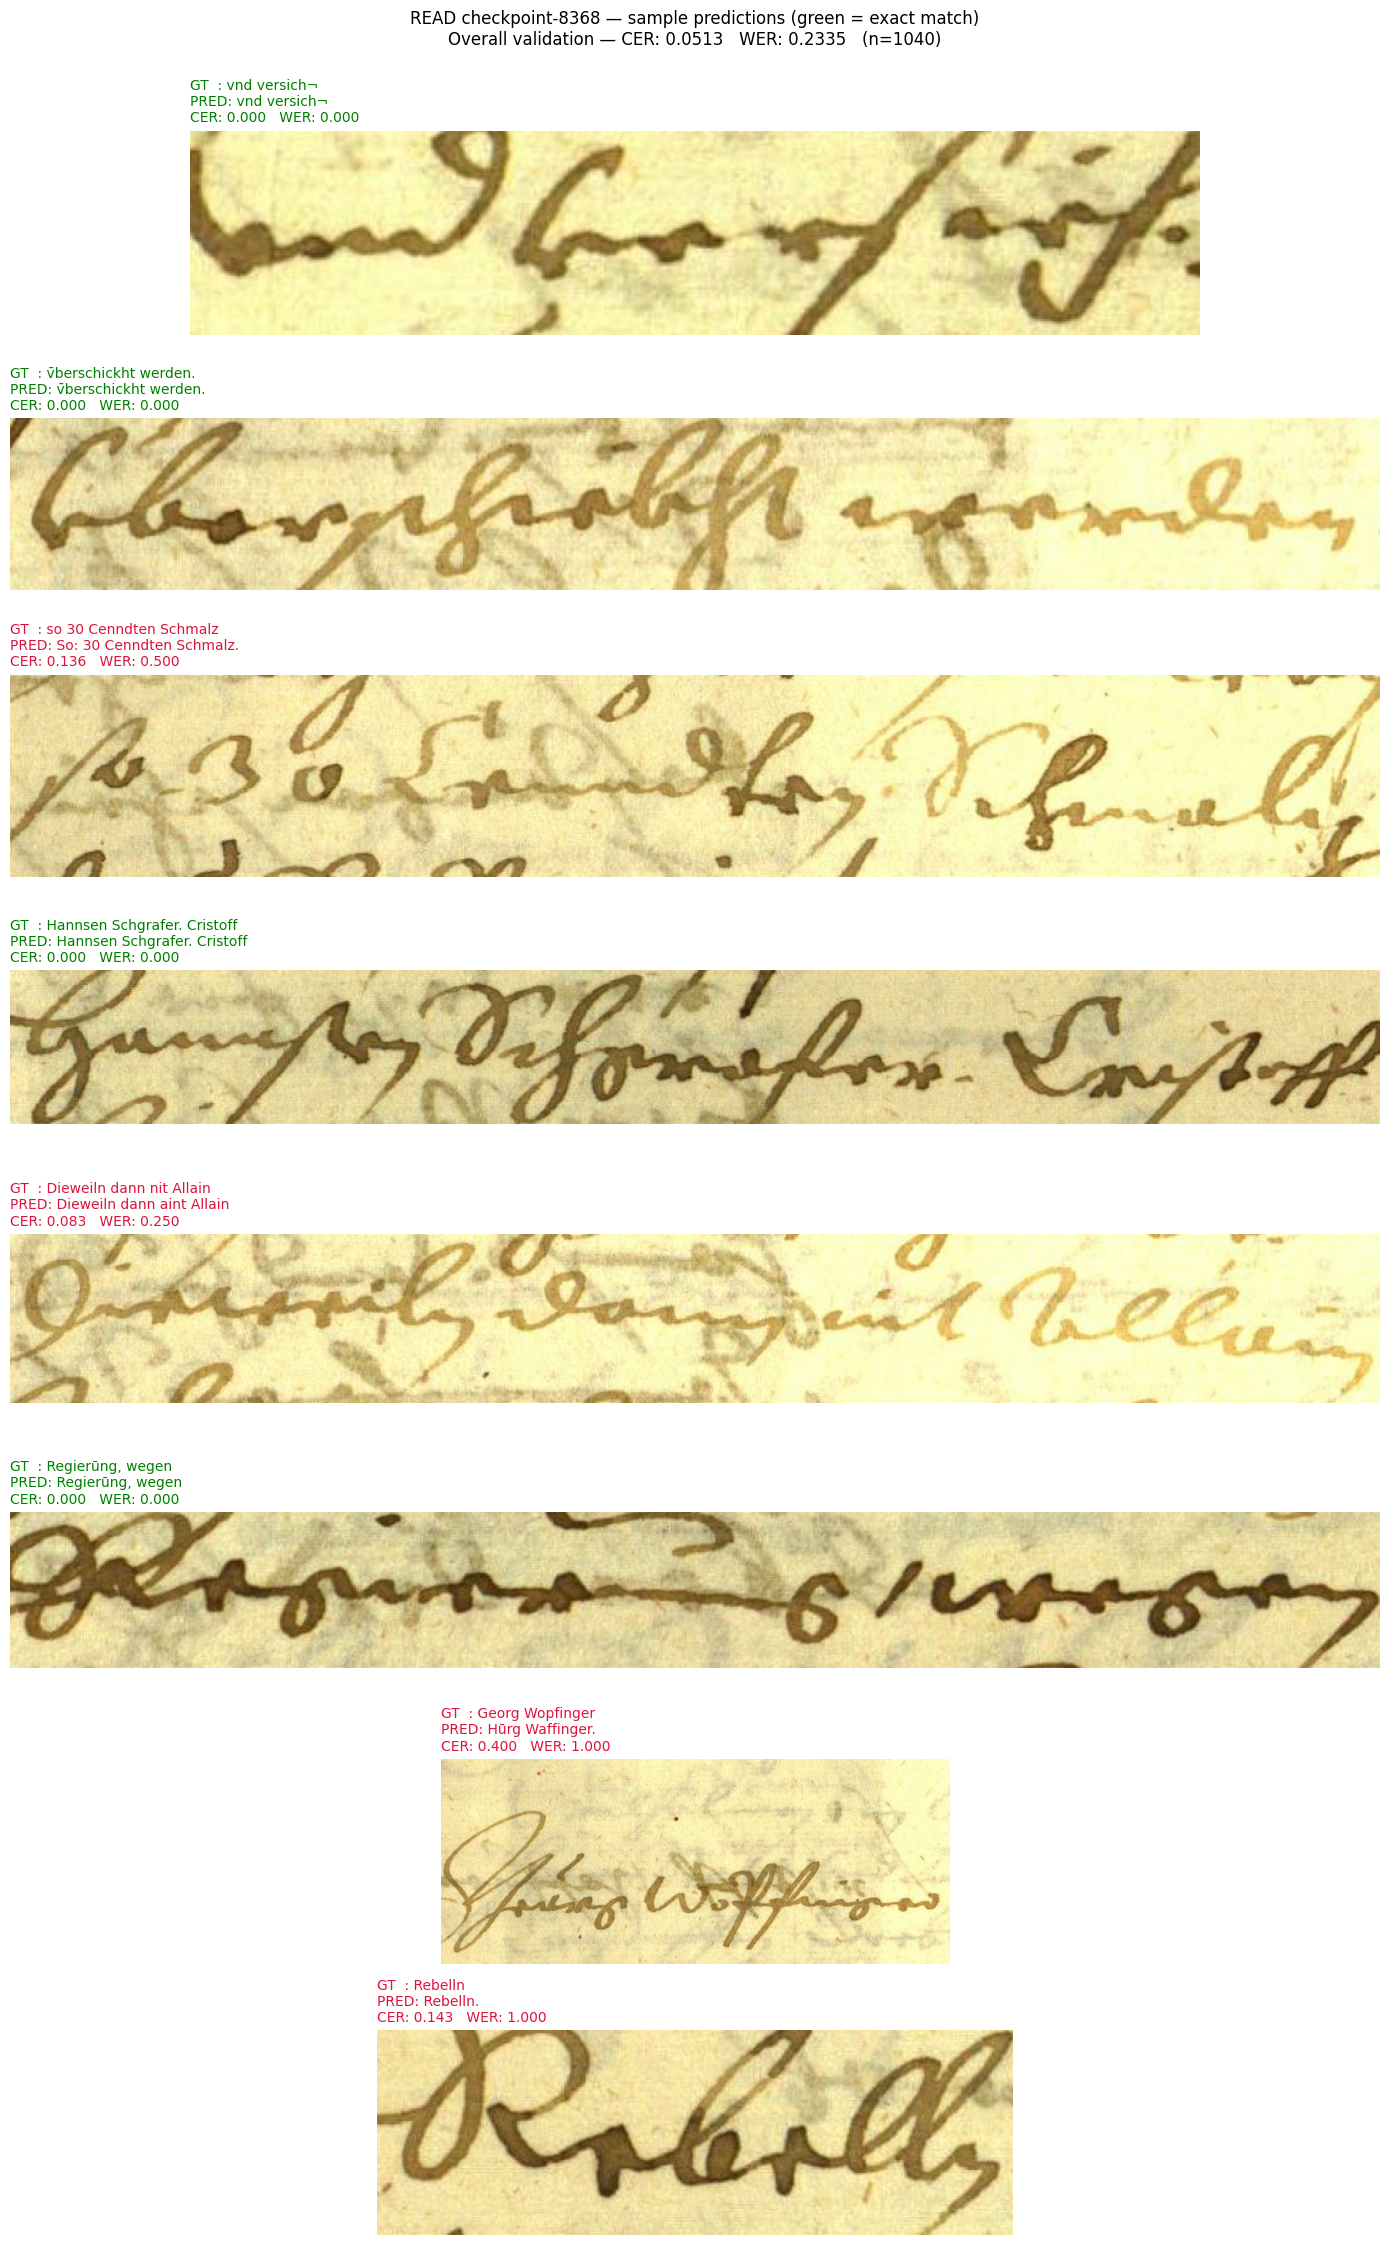

In [21]:
# --- Visualise sample predictions: line crop + ground-truth + prediction + scores ---
# Picks N random validation lines, runs the loaded eval_model on each, and shows the
# crop with GT, PRED and that line's CER / WER. Title is green when the prediction
# matches GT exactly, red otherwise.
N_SHOW = 8
sample = val_df.sample(min(N_SHOW, len(val_df)), random_state=42).reset_index(drop=True)

eval_model.eval()
fig, axes = plt.subplots(len(sample), 1, figsize=(14, 2.8 * len(sample)))
if len(sample) == 1:
    axes = [axes]

with torch.no_grad():
    for ax, row in zip(axes, sample.itertuples()):
        image = Image.open(row.file_name).convert("RGB")
        # eval_transforms (grayscale -> 3ch) matches how val_dataset is preprocessed
        proc_image = eval_transforms(image)
        pixel_values = processor(proc_image, return_tensors="pt").pixel_values.to(device)
        generated_ids = eval_model.generate(
            pixel_values, max_length=MAX_TARGET_LENGTH, num_beams=NUM_BEAMS,
        )
        pred = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

        # per-line scores (single-reference CER / WER)
        line_cer = cer_metric.compute(predictions=[pred], references=[row.text])
        line_wer = wer_metric.compute(predictions=[pred], references=[row.text])
        match = pred.strip() == row.text.strip()

        ax.imshow(image, cmap="gray")
        ax.set_title(f"GT  : {row.text}\nPRED: {pred}\nCER: {line_cer:.3f}   WER: {line_wer:.3f}",
                     fontsize=10, loc="left",
                     color="green" if match else "crimson")
        ax.axis("off")

# overall scores across the whole validation set (computed in the eval cell above)
plt.suptitle(
    f"READ checkpoint-8368 — sample predictions (green = exact match)\n"
    f"Overall validation — CER: {final_cer:.4f}   WER: {final_wer:.4f}   (n={len(all_refs)})",
    y=1.0,
)
plt.tight_layout()
plt.show()

10 worst lines by CER:
  CER 1.250  WER 1.000
    GT  : amus
    PRED: :arner

  CER 1.000  WER 1.000
    GT  : :ist
    PRED: 79

  CER 0.800  WER 1.000
    GT  : Hans Twing
    PRED: hans Sämach¬

  CER 0.733  WER 1.500
    GT  : Joseff Foresst.
    PRED: Zoss Pfsterer St¬

  CER 0.667  WER 1.000
    GT  : 180
    PRED: 166

  CER 0.667  WER 1.000
    GT  : ära
    PRED: ara.

  CER 0.667  WER 1.000
    GT  : Carāra
    PRED: Särärä

  CER 0.600  WER 1.000
    GT  : :mit:
    PRED: nit.

  CER 0.429  WER 1.000
    GT  : Carära.
    PRED: Carbara

  CER 0.400  WER 1.000
    GT  : Georg Wopfinger
    PRED: Hūrg Waffinger.



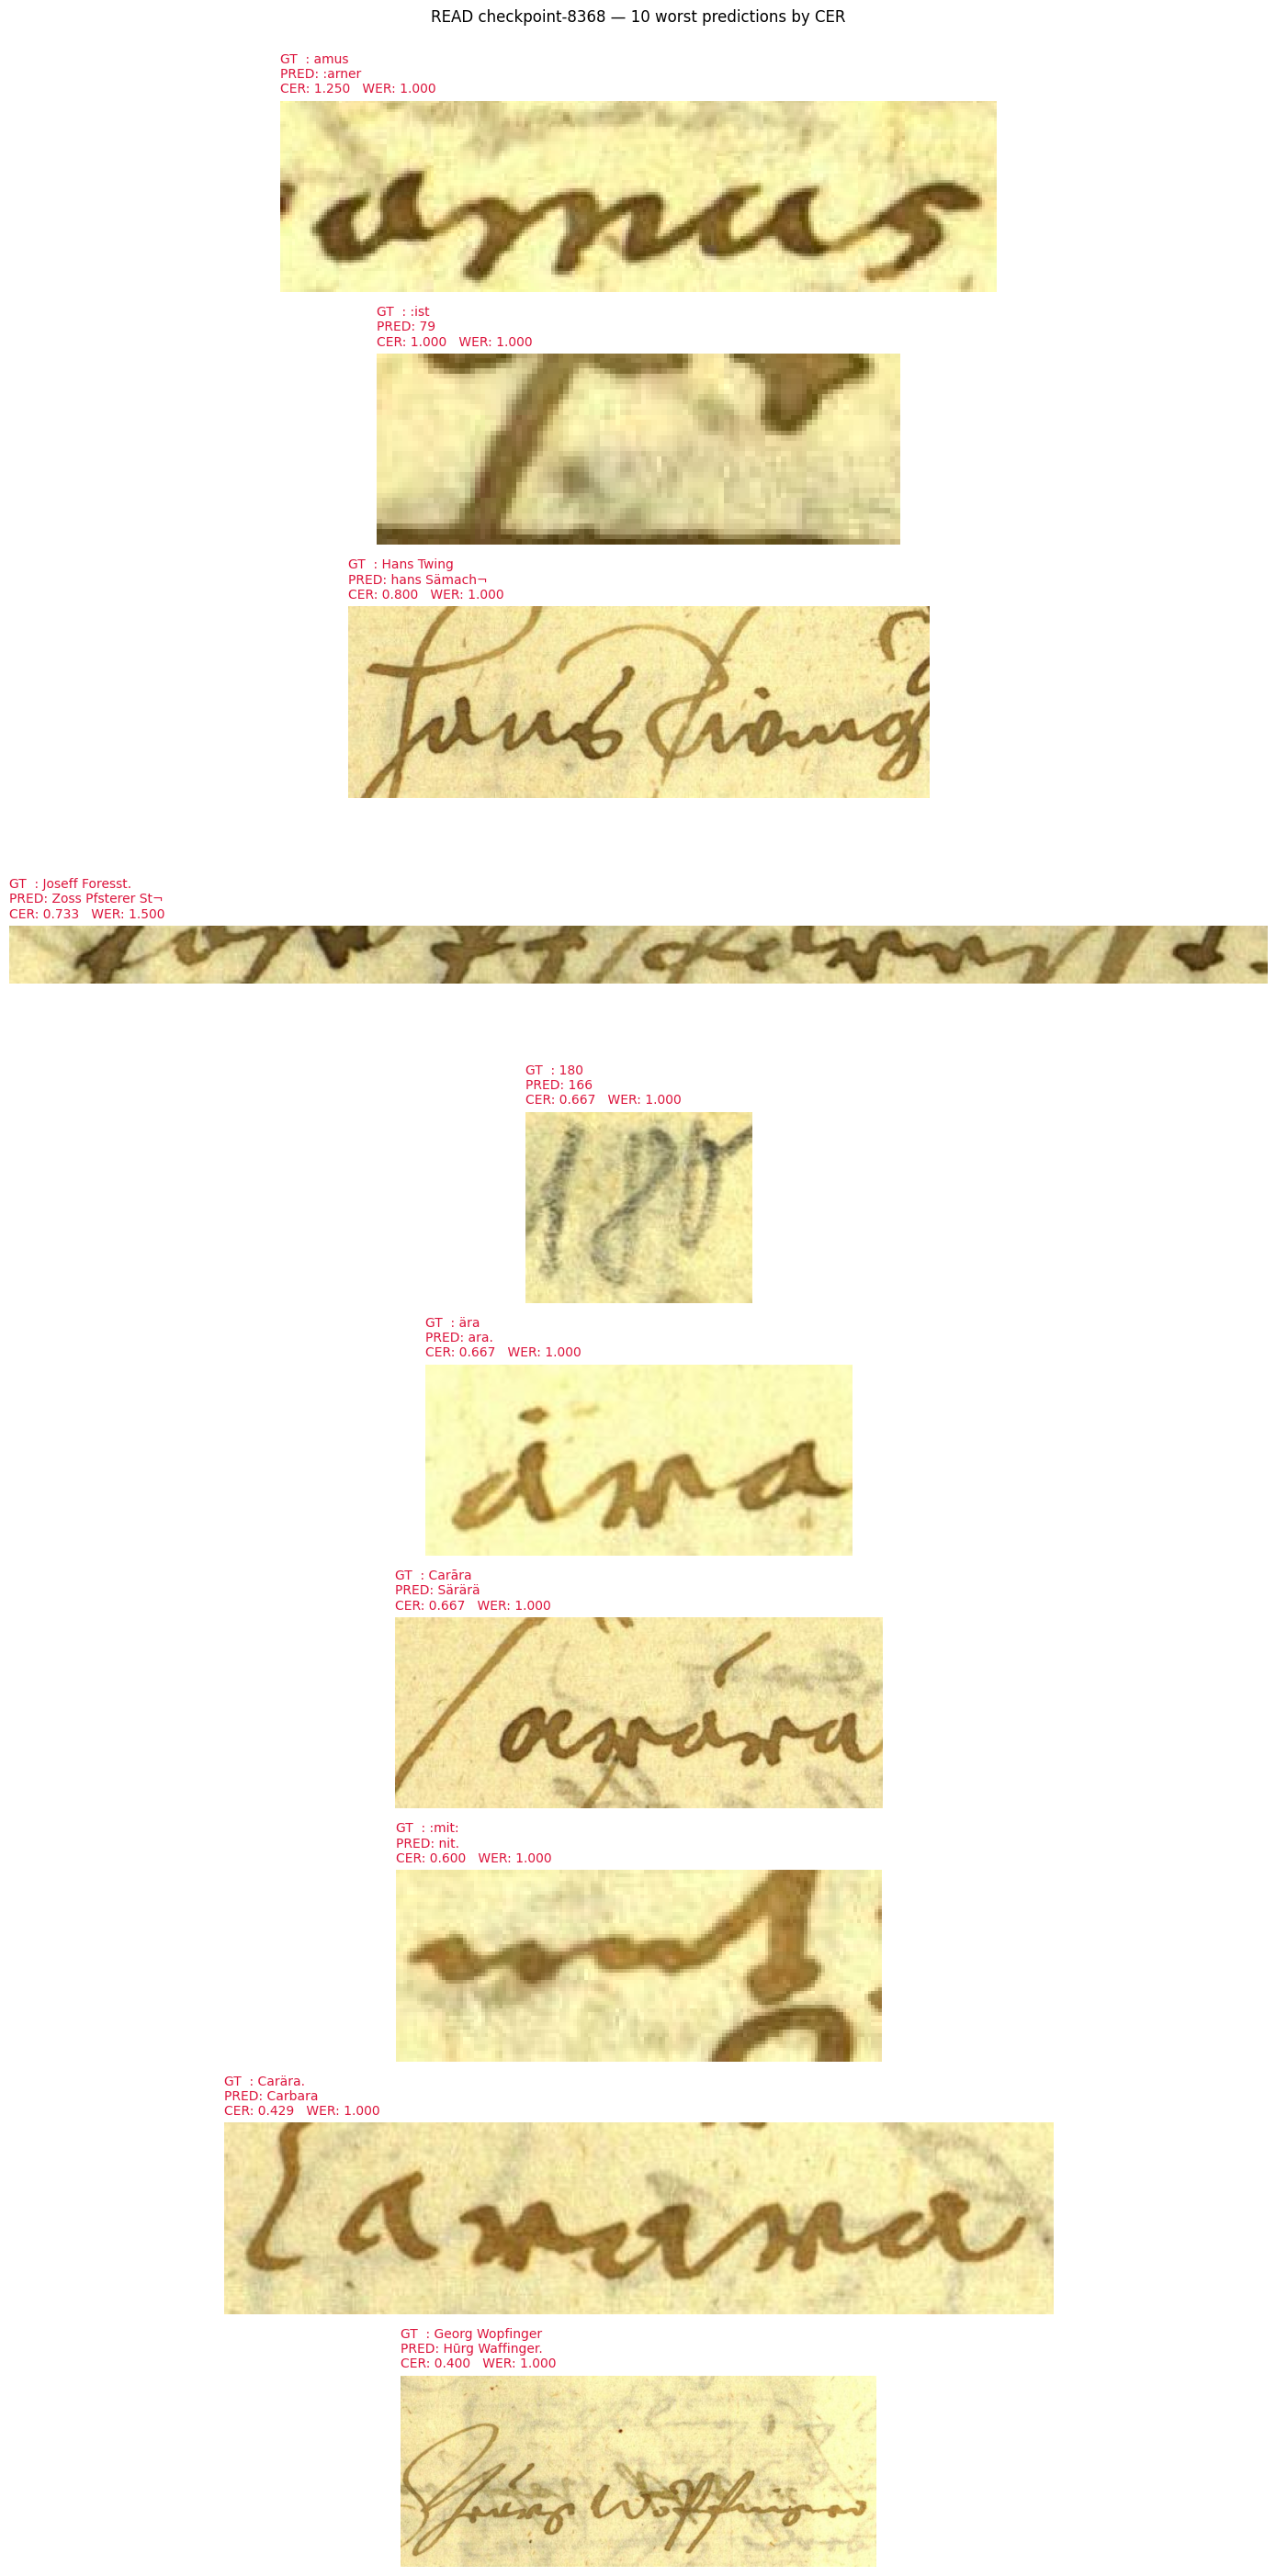

In [22]:
# --- 10 worst predictions by CER (tie-break WER) ---
# all_preds / all_refs come from the eval cell and are aligned with val_df row order
# (the DataLoader used shuffle=False), so index i maps to val_df.iloc[i].
assert len(all_preds) == len(val_df), "Re-run the eval cell so all_preds aligns with val_df"

per_line = []
for i, (pred, ref) in enumerate(zip(all_preds, all_refs)):
    c = cer_metric.compute(predictions=[pred], references=[ref])
    w = wer_metric.compute(predictions=[pred], references=[ref])
    per_line.append({"idx": i, "cer": c, "wer": w,
                     "file_name": val_df["file_name"].iloc[i],
                     "gt": ref, "pred": pred})

worst = sorted(per_line, key=lambda r: (r["cer"], r["wer"]), reverse=True)[:10]

print("10 worst lines by CER:")
for r in worst:
    print(f"  CER {r['cer']:.3f}  WER {r['wer']:.3f}")
    print(f"    GT  : {r['gt']}")
    print(f"    PRED: {r['pred']}\n")

fig, axes = plt.subplots(len(worst), 1, figsize=(14, 2.8 * len(worst)))
if len(worst) == 1:
    axes = [axes]
for ax, r in zip(axes, worst):
    ax.imshow(Image.open(r["file_name"]).convert("RGB"), cmap="gray")
    ax.set_title(f"GT  : {r['gt']}\nPRED: {r['pred']}\nCER: {r['cer']:.3f}   WER: {r['wer']:.3f}",
                 fontsize=10, loc="left", color="crimson")
    ax.axis("off")
plt.suptitle("READ checkpoint-8368 — 10 worst predictions by CER", y=1.0)
plt.tight_layout()
plt.show()